# 2. Análisis Exploratorio de Datos (EDA)

**Punto de partida:** el dataset crudo descargado en `1_GetData.ipynb` (`../data/WA_Fn-UseC_-Telco-Customer-Churn.csv`).

En inglés se conoce como **Exploratory Data Analysis (EDA)**; según [IBM](https://www.ibm.com/think/topics/exploratory-data-analysis), es la fase del proceso analítico en la que buscamos comprender los datos antes de limpiarlos, transformarlos o construir modelos predictivos. El objetivo principal no es obtener conclusiones definitivas, sino formular hipótesis, detectar problemas de calidad y entender el comportamiento general de la información.

### ¿Por qué es importante?
En proyectos reales, la mayor parte de los errores no proviene del algoritmo, sino de un entendimiento insuficiente de los datos y del contexto de negocio.

* Identificar datos faltantes.
* Detectar valores atípicos.
* Comprender la distribución de las variables.
* Encontrar relaciones entre variables.
* Verificar supuestos iniciales.
* Priorizar variables relevantes para el modelado.

**Entrega de este notebook:** ningún archivo nuevo — el EDA es puramente diagnóstico. Los hallazgos (nulos en `TotalCharges`, variables candidatas a transformar, correlaciones) se usan como insumo de decisiones en `3_FeatureEngineering.ipynb`.

Se importan `pandas` para manipulación de datos y `seaborn`/`matplotlib` para las visualizaciones univariadas y bivariadas que se construyen a lo largo del notebook.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

## Cargar datos

Se lee el dataset crudo generado por `1_GetData.ipynb`, sin ningún parámetro adicional de limpieza, para observar los datos exactamente como llegan de la fuente.

In [ ]:
import os, glob, shutil, kagglehub

import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

carpetas_requeridas = ["../data", "../models", "../output"]

for carpeta in carpetas_requeridas:
    os.makedirs(carpeta, exist_ok=True)

print("Carpetas verificadas/creadas:", carpetas_requeridas)

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
files = [f.replace("\\","/") for f in glob.glob( path.replace("\\","/") + "/*", recursive=True) if os.path.isfile(f)]
resp = [shutil.copy(f, "../data/" + os.path.basename(f)) for f in files]
fName = resp[0]
print("Path to dataset files:", resp[0])
print(f"Archivos descargados: {len(resp)}")
print("\t* "+ "\n\t* ".join(resp))

In [10]:
fName = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

data = pd.read_csv(
                    fName
                    # , sep=",", na_values=[""," ","-","NA"]
                )
print("Dimensiones del Dataframe:", data.shape)
data.head()

Dimensiones del Dataframe: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Análisis Exploratorio de Datos

Se trabaja sobre una **copia** (`df`) del dataset original (`data`), buena práctica que permite conservar siempre disponible la versión cruda por si se necesita comparar o reiniciar el análisis.

In [4]:
## creando una copia
df = data.copy()
print("Dimensiones del Dataframe:", df.shape)
df.head()

Dimensiones del Dataframe: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Se fija explícitamente el nombre de la variable objetivo en una sola variable (`target`), para no repetir el string `"Churn"` en el resto del notebook y facilitar cambios futuros.

In [5]:
# La variable target que corresponde a el comportamiento esperado.
target = "Churn"

### Revisión de tipos de datos

`df.info()` es el primer chequeo estructural: número de registros, nulos por columna y tipo de dato asignado por pandas. Aquí se detecta la primera inconsistencia: `TotalCharges` debería ser numérica, pero pandas la interpretó como texto (`object`).

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Se intenta convertir `TotalCharges` a numérico. El error que arroja esta celda **es intencional**: confirma que existen valores no convertibles directamente (no son nulos vacíos, sino texto no numérico, típicamente espacios en blanco).

In [7]:
pd.to_numeric(df["TotalCharges"])

ValueError: Unable to parse string " " at position 488

Se usa `errors="coerce"` para identificar puntualmente cuáles registros no se pueden convertir (quedan como `NaN`), y se filtran para inspeccionarlos.

In [8]:
## validando por que no se puede convertir
df[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Se aplica la conversión definitiva con `errors="coerce"`: los valores no numéricos se convierten en `NaN` (nulos), y ahora se revisa nuevamente `df.info()` para confirmar que `TotalCharges` ya quedó como tipo numérico (`float64`).

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Revisión de cardinalidad

Se cuenta el número de valores únicos por columna. Esto ayuda a distinguir variables categóricas (pocos valores distintos) de variables continuas o identificadoras (muchos valores distintos, potencialmente únicos por registro).

In [11]:
print("Revision de datos unicos por variable:")
df.nunique()

Revision de datos unicos por variable:


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

`customerID` tiene tantos valores únicos como registros tiene el dataset, lo que confirma que es un identificador único por cliente. Por lo tanto, se puede usar como índice del `DataFrame` en lugar de tratarlo como una variable analítica más.

In [12]:
df.set_index("customerID", inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Distribución de variables categóricas / de baja cardinalidad

Para las variables con 10 o menos valores distintos (típicamente categóricas o binarias), se revisa la proporción de cada categoría. Esto permite detectar clases dominantes, categorías raras o posibles errores de captura antes de pasar al análisis gráfico.

In [13]:
print("Distribucion de valores por cada variable (con una cardinalidad <=10):")
cols = df.nunique()[df.nunique()<=10].index
for c in cols:
    print(f"\t{c:<16}", [f"{k}: {v:,.1%}" for k,v in dict(df[c].value_counts(normalize=True)).items()])

Distribucion de valores por cada variable (con una cardinalidad <=10):
	gender           ['Male: 50.5%', 'Female: 49.5%']
	SeniorCitizen    ['0: 83.8%', '1: 16.2%']
	Partner          ['No: 51.7%', 'Yes: 48.3%']
	Dependents       ['No: 70.0%', 'Yes: 30.0%']
	PhoneService     ['Yes: 90.3%', 'No: 9.7%']
	MultipleLines    ['No: 48.1%', 'Yes: 42.2%', 'No phone service: 9.7%']
	InternetService  ['Fiber optic: 44.0%', 'DSL: 34.4%', 'No: 21.7%']
	OnlineSecurity   ['No: 49.7%', 'Yes: 28.7%', 'No internet service: 21.7%']
	OnlineBackup     ['No: 43.8%', 'Yes: 34.5%', 'No internet service: 21.7%']
	DeviceProtection ['No: 43.9%', 'Yes: 34.4%', 'No internet service: 21.7%']
	TechSupport      ['No: 49.3%', 'Yes: 29.0%', 'No internet service: 21.7%']
	StreamingTV      ['No: 39.9%', 'Yes: 38.4%', 'No internet service: 21.7%']
	StreamingMovies  ['No: 39.5%', 'Yes: 38.8%', 'No internet service: 21.7%']
	Contract         ['Month-to-month: 55.0%', 'Two year: 24.1%', 'One year: 20.9%']
	PaperlessBilling ['

In [14]:
print("Datos estadisticos para variables numericas:")
df.describe().T

Datos estadisticos para variables numericas:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


### Valores nulos

Ante registros con valores nulos o vacíos, las alternativas típicas son:
* Imputar (reemplazar por un valor estimado).
* Eliminar el registro.

La decisión correcta depende de cuántos registros están afectados y si su eliminación introduce sesgo en la variable objetivo.

In [15]:
print("Registros con nulos:")
filtro_nulos = df.isnull().sum(axis=1)>0
df[filtro_nulos]

Registros con nulos:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No


In [16]:
print("Revision de nulos:")
nulos = df.isnull().sum()
pd.concat([nulos[nulos>0], round(nulos[nulos>0]/len(df)*100,2)], axis=1).rename(columns={0:"Nulos", 1:"%"})

Revision de nulos:


,Nulos,%
TotalCharges,11,0.16


In [17]:
print(f"Distribucion de los nulos con respecto al {target=}: {dict(df[filtro_nulos][target].value_counts())}")
print(f"Distribucion del target:", dict(df[target].value_counts()))

Distribucion de los nulos con respecto al target='Churn': {'No': np.int64(11)}
Distribucion del target: {'No': np.int64(5174), 'Yes': np.int64(1869)}


**Decisión:** la opción más favorable en este caso es eliminar los registros, ya que representan una fracción mínima del dataset (0.16% del total) y además pertenecen a la clase mayoritaria del target, por lo que su eliminación no introduce un sesgo relevante en la variable objetivo.

In [18]:
df = df[~filtro_nulos]
print("Dimensiones del Dataframe:", df.shape)
df.head()

Dimensiones del Dataframe: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
print(f"items nulos = {df.isnull().sum().sum()}")

items nulos = 0


### Clasificación de variables: numéricas vs. categóricas

Separar explícitamente las variables numéricas de las categóricas facilita aplicar el tipo de análisis (y de transformación, en el módulo siguiente) adecuado a cada grupo.

In [20]:
# Variables numericas
cols_num = df.select_dtypes(["int","float"]).columns
df[cols_num]

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
customerID,,,,
7590-VHVEG,0,1,29.85,29.85
5575-GNVDE,0,34,56.95,1889.50
3668-QPYBK,0,2,53.85,108.15
7795-CFOCW,0,45,42.30,1840.75
9237-HQITU,0,2,70.70,151.65
...,...,...,...,...
6840-RESVB,0,24,84.80,1990.50
2234-XADUH,0,72,103.20,7362.90
4801-JZAZL,0,11,29.60,346.45


In [21]:
cols_num

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [22]:
cols_cat = df.drop(cols_num, axis=1).columns
# cols_cat = df.select_dtypes(["str","object"]).columns
df[cols_cat]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
customerID,,,,,,,,,,,,,,,,
7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No


## Estadísticas descriptivas

Solo aplican directamente sobre las variables numéricas: medidas de tendencia central (media, mediana) y de dispersión (desviación estándar, rango), útiles para detectar asimetrías o valores atípicos.

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


### Análisis univariado

Se revisa la distribución individual de las variables más relevantes, comenzando por la variable objetivo.

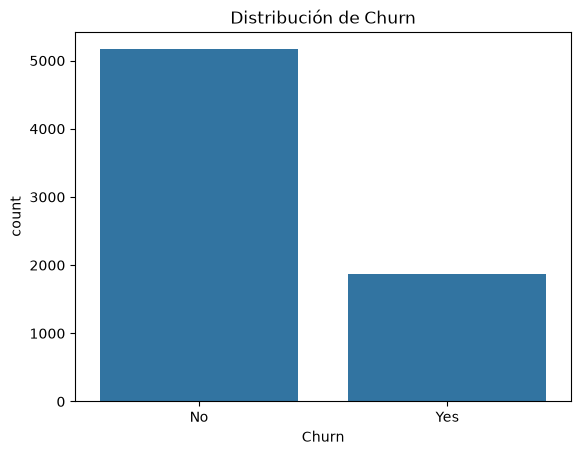

In [24]:
sns.countplot(data=df, x="Churn")
plt.title("Distribución de Churn")
plt.show()

Distribución de la antigüedad del cliente (`tenure`, en meses).

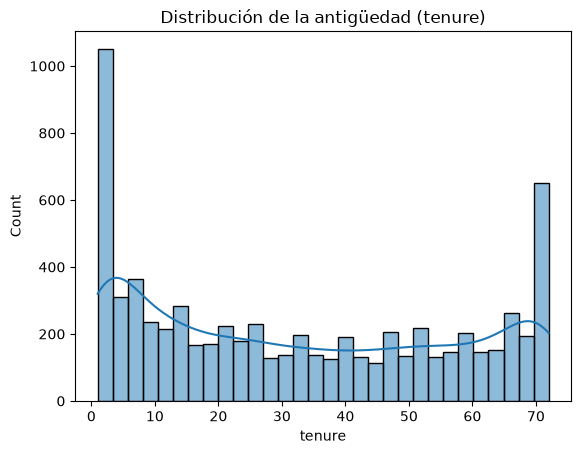

In [25]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribución de la antigüedad (tenure)")
plt.show()

Distribución de los cargos mensuales (`MonthlyCharges`).

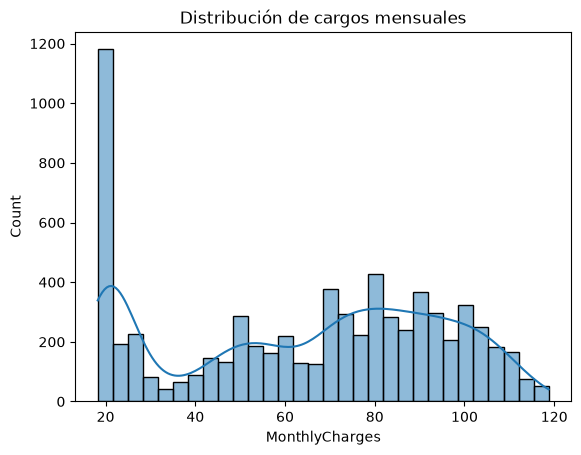

In [26]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribución de cargos mensuales")
plt.show()

Misma variable, pero normalizando el histograma como **densidad de probabilidad** (`stat="probability"`) en lugar de conteos absolutos. Esto es útil cuando se quiere comparar la forma de la distribución independientemente del tamaño de la muestra, o compararla más adelante contra otra variable con distinta escala de conteo.

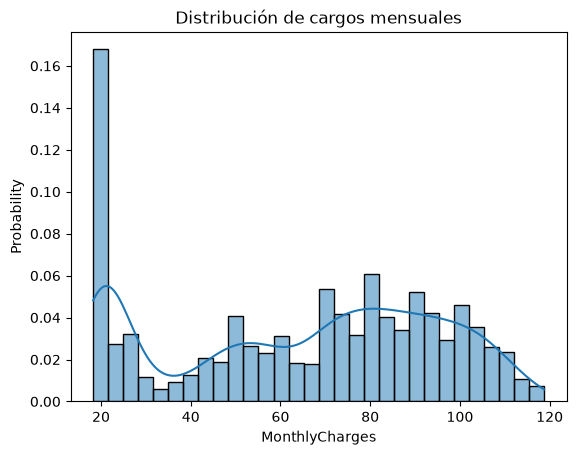

In [27]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, stat="probability")
plt.title("Distribución de cargos mensuales")
plt.show()

Distribución de los cargos totales acumulados (`TotalCharges`).

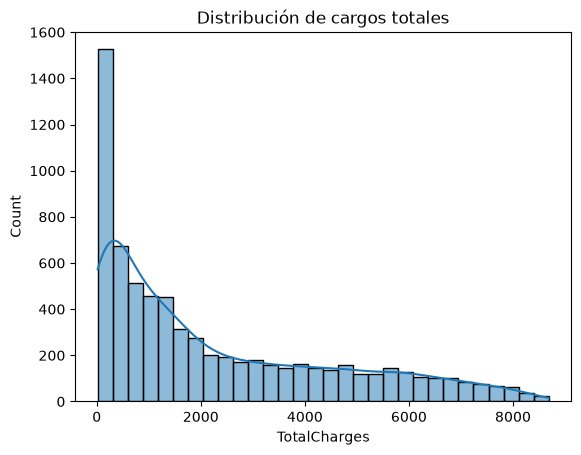

In [28]:
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribución de cargos totales")
plt.show()

### Análisis bivariado: relación con la variable objetivo

A partir de aquí se cruzan las variables con `Churn`, para identificar diferencias de comportamiento entre clientes que abandonan y los que permanecen.

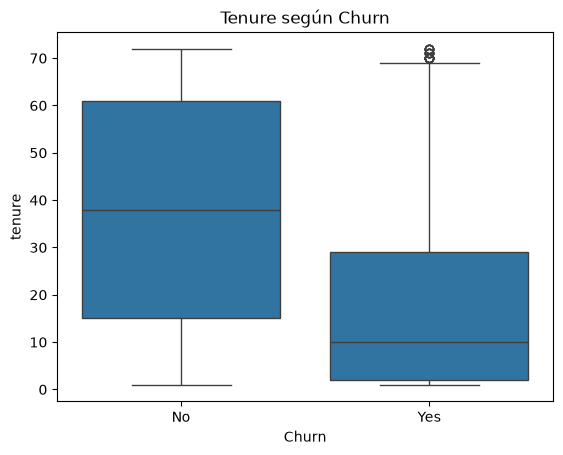

In [29]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure según Churn")
plt.show()

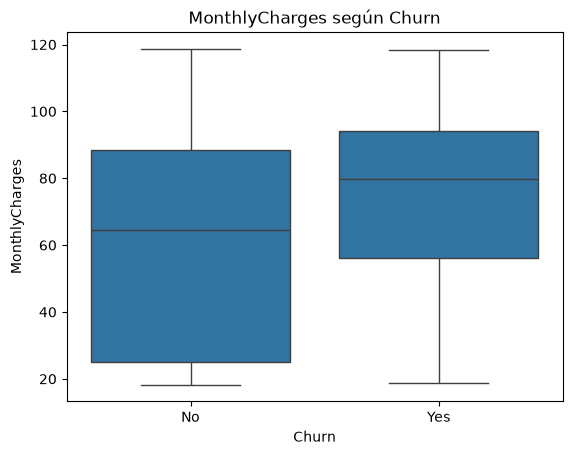

In [30]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("MonthlyCharges según Churn")
plt.show()

Relación conjunta entre antigüedad y cargo mensual, coloreada por `Churn`, para observar visualmente si existen zonas del espacio con mayor concentración de abandono.

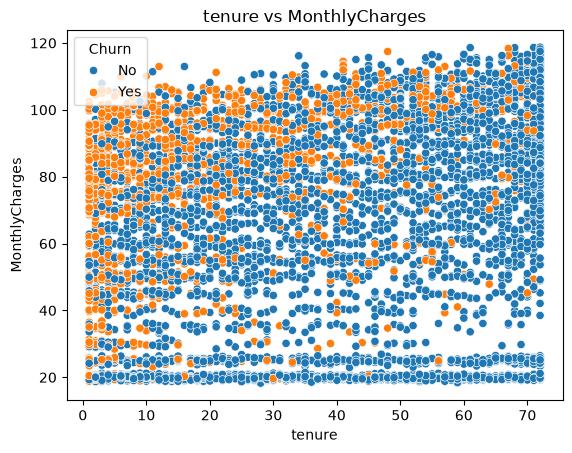

In [ ]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", alpha=0.4, hue=target)
plt.title("tenure vs MonthlyCharges")
plt.show()

Proporción de churn según el tipo de contrato (tabla de contingencia normalizada por fila).

In [33]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


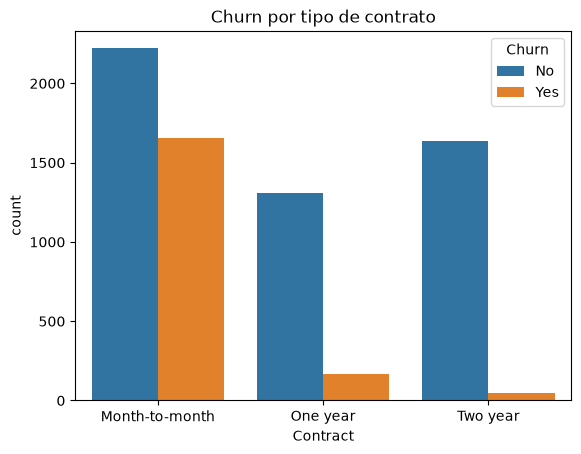

In [34]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn por tipo de contrato")
plt.show()

Distribución de churn según método de pago.

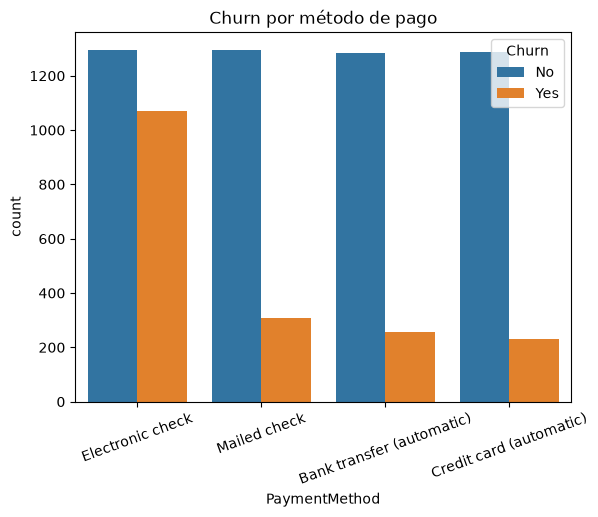

In [35]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=20)
plt.title("Churn por método de pago")
plt.show()

Distribución de churn según tipo de servicio de internet contratado.

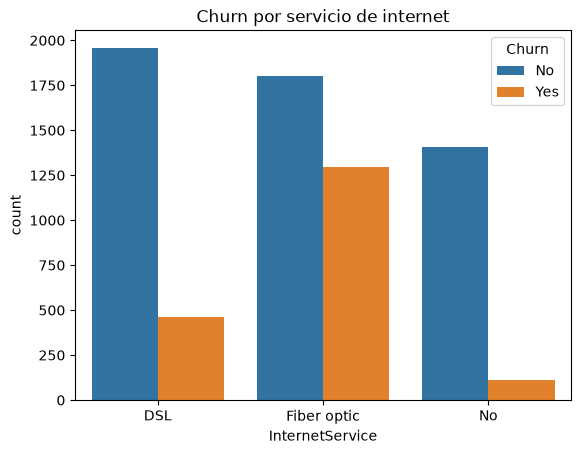

In [36]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn por servicio de internet")
plt.show()

### Correlación entre variables numéricas

La matriz de correlación ayuda a detectar relaciones lineales fuertes entre variables numéricas, útil tanto para entender el negocio como para anticipar posible redundancia de variables en el modelado.

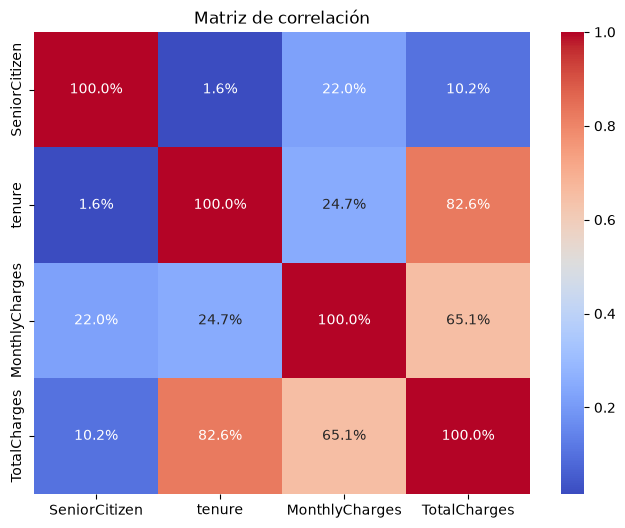

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(df[cols_num].corr(), annot=True, cmap="coolwarm", fmt=".1%")
plt.title("Matriz de correlación")
plt.show()

### Análisis exploratorio generalizado por variable

En lugar de repetir manualmente el mismo gráfico para cada variable, se automatiza el recorrido: para cada columna categórica se calcula la proporción de churn por categoría, y para cada columna numérica se compara su distribución entre las dos clases del target. Esto agiliza detectar rápidamente qué variables muestran mayor asociación aparente con el abandono.

### Vista previa de una sola variable antes de generalizar

Antes de automatizar el recorrido por todas las variables (siguiente celda), conviene revisar el resultado sobre **una sola variable conocida** (`MonthlyCharges`) para confirmar que la lógica es la esperada: comparar estadísticas descriptivas y distribución entre clientes con y sin `Churn`.

In [38]:
c="MonthlyCharges"

In [39]:
distribucion_target = df[[target, c]].groupby(target).describe()
distribucion_target.columns = [x[1] for x in distribucion_target.columns]
distribucion_target

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


<Axes: ylabel='MonthlyCharges'>

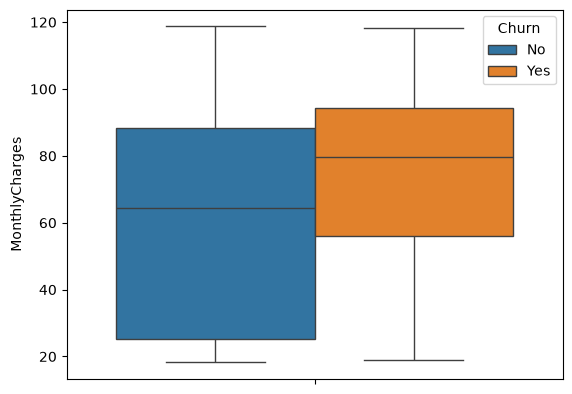

In [40]:
sns.boxplot(data=df, hue=target, y=c)

**Nota:** las dos celdas siguientes generalizan a *todas* las variables la misma lógica que acabas de ver para `MonthlyCharges` (comparar la distribución de cada variable entre clientes con y sin `Churn`), recorriendo las columnas con un bucle `for`. No necesitas entender el código línea por línea — concéntrate en leer los gráficos que produce, uno por variable.

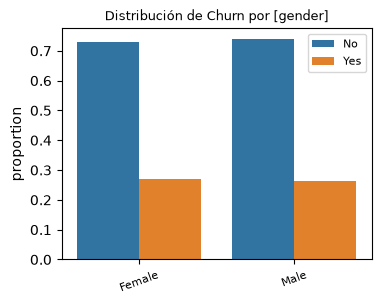

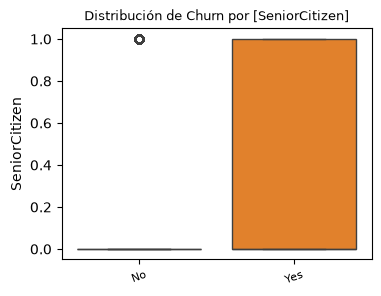

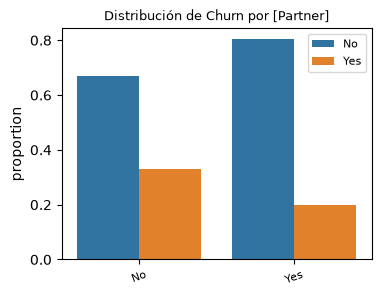

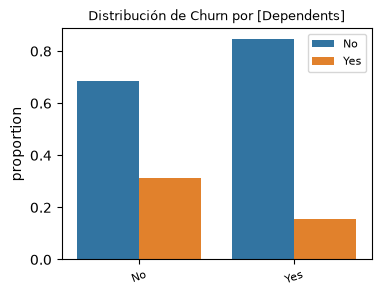

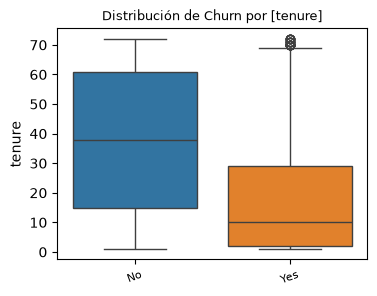

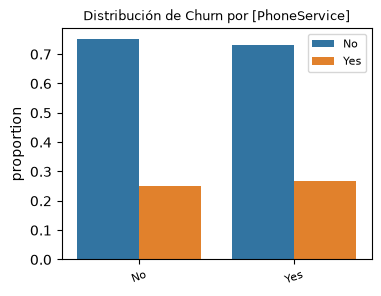

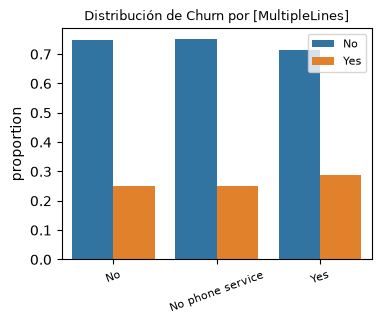

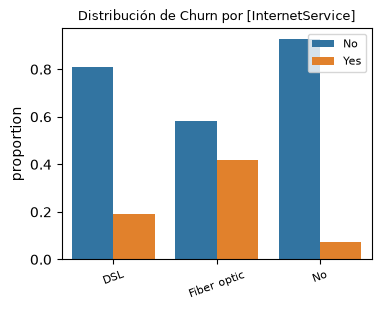

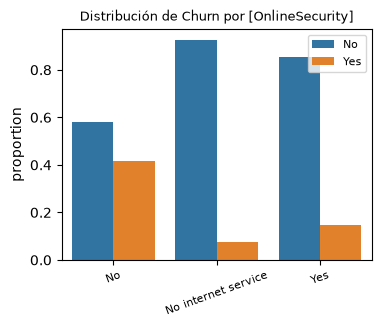

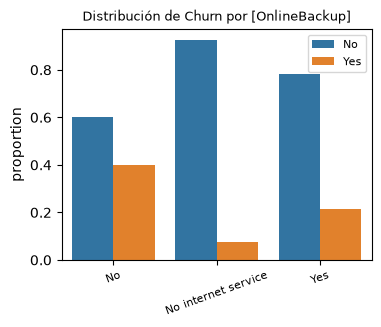

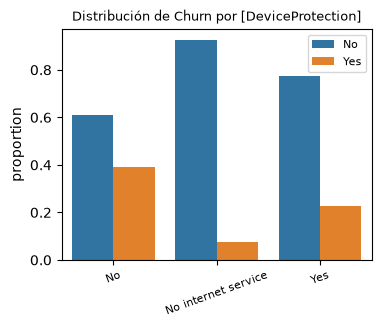

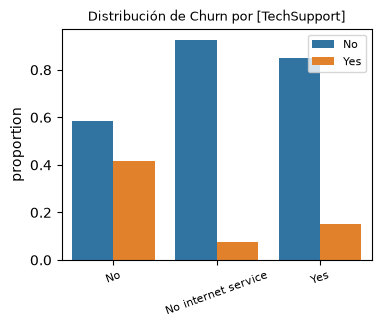

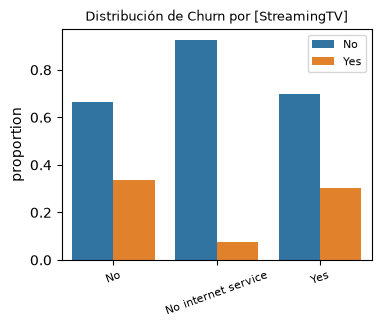

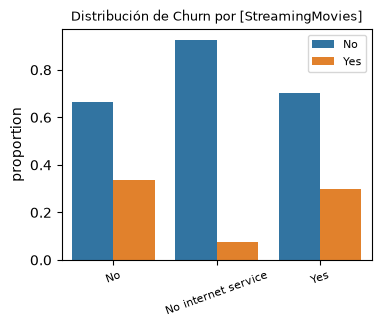

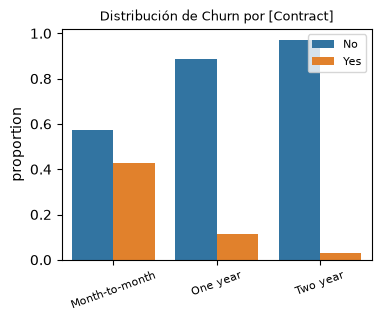

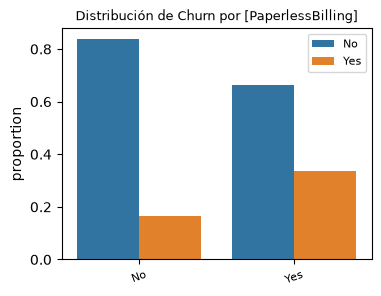

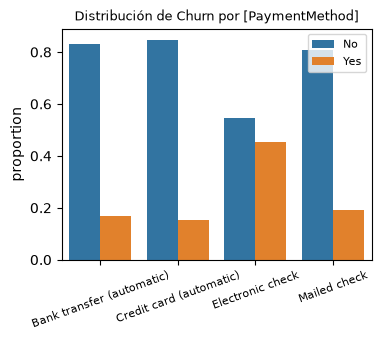

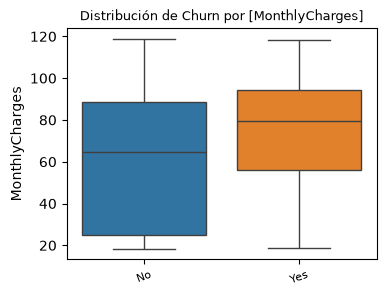

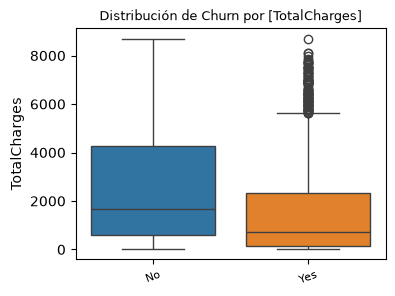

In [41]:
for c,t in df.drop(target, axis=1).dtypes.items():
    if t.name in ["str","object"]:
        distribucion_target = pd.crosstab(index=df[c], columns=df[target], values=target, aggfunc="count", normalize="index")
        distribucion_target = distribucion_target.unstack().reset_index().rename(columns={0:"proportion"})

        plt.figure(figsize=(4,3))
        sns.barplot(data=distribucion_target, x=c, y="proportion", hue=target)
        plt.title(f"Distribución de {target} por [{c}]", size=9)
        plt.legend(loc="upper right", fontsize=8)
        plt.xticks(rotation=20, fontsize=8)
        plt.xlabel(None)
        plt.show()
    else:
        plt.figure(figsize=(4,3))
        sns.boxplot(data=df, x=target, hue=target, y=c)
        plt.title(f"Distribución de {target} por [{c}]", size=9)
        plt.xticks(rotation=20, fontsize=8)
        plt.xlabel(None)
        plt.show()


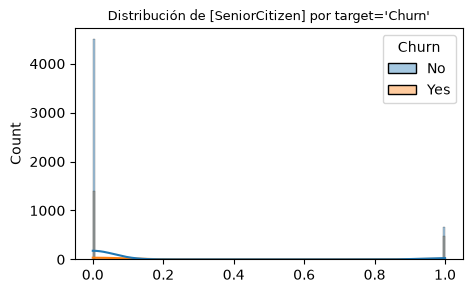

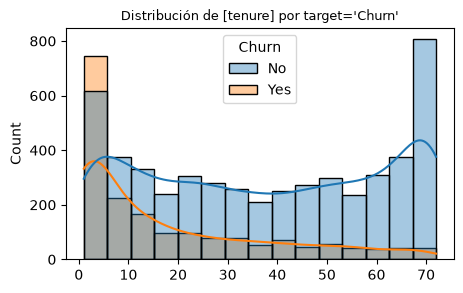

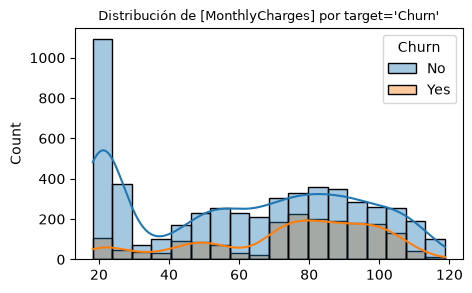

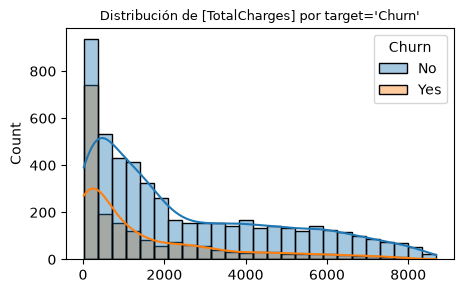

In [42]:
for c,t in df.drop(target, axis=1).dtypes.items():
    if t.name in ["str","object"]:
        pass
    else:
        plt.figure(figsize=(5,3))
        sns.histplot(data=df, x=c, hue=target, kde=True, alpha=0.4)
        plt.title(f"Distribución de [{c}] por {target=}", size=9)
        # plt.xticks(rotation=20, fontsize=8)
        plt.xlabel(None)
        plt.show()

## Preguntas orientadoras del EDA

* ¿Qué características tienen los clientes que abandonan la compañía?
* ¿Cómo se comporta la antigüedad de los clientes?
* ¿Qué servicios son más frecuentes?
* ¿Existen diferencias en los cargos mensuales?
* ¿Qué métodos de pago predominan?
* ¿Hay variables con posibles problemas de calidad?

## Resultados esperados del EDA:

1. Comprensión de la estructura del dataset
    * Número de filas y columnas.
    * Tipos de datos.
    * Variables categóricas y numéricas.
    * Variable objetivo (Churn).

2. Calidad inicial de los datos
    * Valores nulos o vacíos.
    * Duplicados.
    * Inconsistencias aparentes.
    * Variables importadas con tipo incorrecto.

3. Análisis univariado
    * Distribuciones numéricas.
    * Frecuencias categóricas.
    * Medidas descriptivas básicas.

4. Análisis bivariado
    * Relación entre variables y Churn.
    * Comparación de grupos.
    * Tendencias y asociaciones.

5. Hallazgos preliminares
    * Patrones observados.
    * Variables potencialmente relevantes.
    * Riesgos o limitaciones de los datos.

<figure>
  <blockquote>
    "El Analisis de Datos Exploratorio (EDA) es el puente entre el conocimiento del negocio y el modelamiento analítico."
  </blockquote>
  <figcaption>— <cite>Diego Herrera Malambo.</cite></figcaption>
</figure>

### Siguiente paso

Los hallazgos de este EDA (nulos en `TotalCharges` asociados a clientes nuevos, variables categóricas pendientes de codificar, correlaciones relevantes con el target) se retoman y se resuelven de forma sistemática en `3_FeatureEngineering.ipynb`, que parte nuevamente del dataset crudo para dejarlo listo para modelado.